# 5.1 — Публикационные панели (Q1)

В статью нельзя вставить все рисунки по отдельности — поэтому ключевые результаты собраны в
**объединённые многопанельные фигуры** журнального качества (пастель, чистый sans-serif,
векторный/300 dpi экспорт). Здесь три панели:

* **Обзор данных** — состав по типам грунта, PLAXIS-классы, e–Vs по исходу, кривые PPR(N);
* **Физика CRR** — кривые CRR(N)=β/N^(1−α), зависимости от D_r и I_p, разложение α/β;
* **Сравнение моделей** — P³-скор, траекторная ошибка, AUROC↔Brier, ошибка N_liq.

Все панели строятся фабрикой `liquefaction_ai.viz.panels` и сохраняются в `results/figs`.

## Окружение, данные и таблицы метрик

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "demo_run"
MODELS_DIR = REPO_ROOT / "models"

from liquefaction_ai import load_population_artifact
from liquefaction_ai.viz import (data_overview_panel, crr_physics_panel, model_leaderboard_panel)
from liquefaction_ai.constants import SOIL_DISPLAY_NAMES_EN

population, config = load_population_artifact(DATA_DIR)
meta = population["meta"].copy()
cycles = population["cycles"]; r_obs = population["r_obs"]; valid_mask = population["valid_mask"]

T = REPO_ROOT / "results" / "tables"
p3 = pd.read_csv(T / "p3_core_ranking.csv")
full = pd.read_csv(T / "full_leaderboard.csv")
mcol = "model" if "model" in full.columns else ("Model" if "Model" in full.columns else full.columns[0])
full = full.rename(columns={mcol: "model"})
keep = [c for c in ["Traj_RMSE", "AUROC", "Brier", "N_liq_logMAE", "N_liq_MAE"] if c in full.columns]
leaderboard = p3[["model", "P3_Core_Raw_Score"]].merge(full[["model", *keep]], on="model", how="left")
print("Источник:", DATA_DIR.name, "| образцов:", len(meta), "| моделей в лидерборде:", len(leaderboard))

Источник: demo_run | образцов: 666 | моделей в лидерборде: 14


## Панель 1 — Обзор данных

Одна фигура 2×2: состав датасета по типам грунта и PLAXIS-классам, связь e–Vs с исходом
испытания и примеры измеренных гладких кривых порового давления PPR(N).

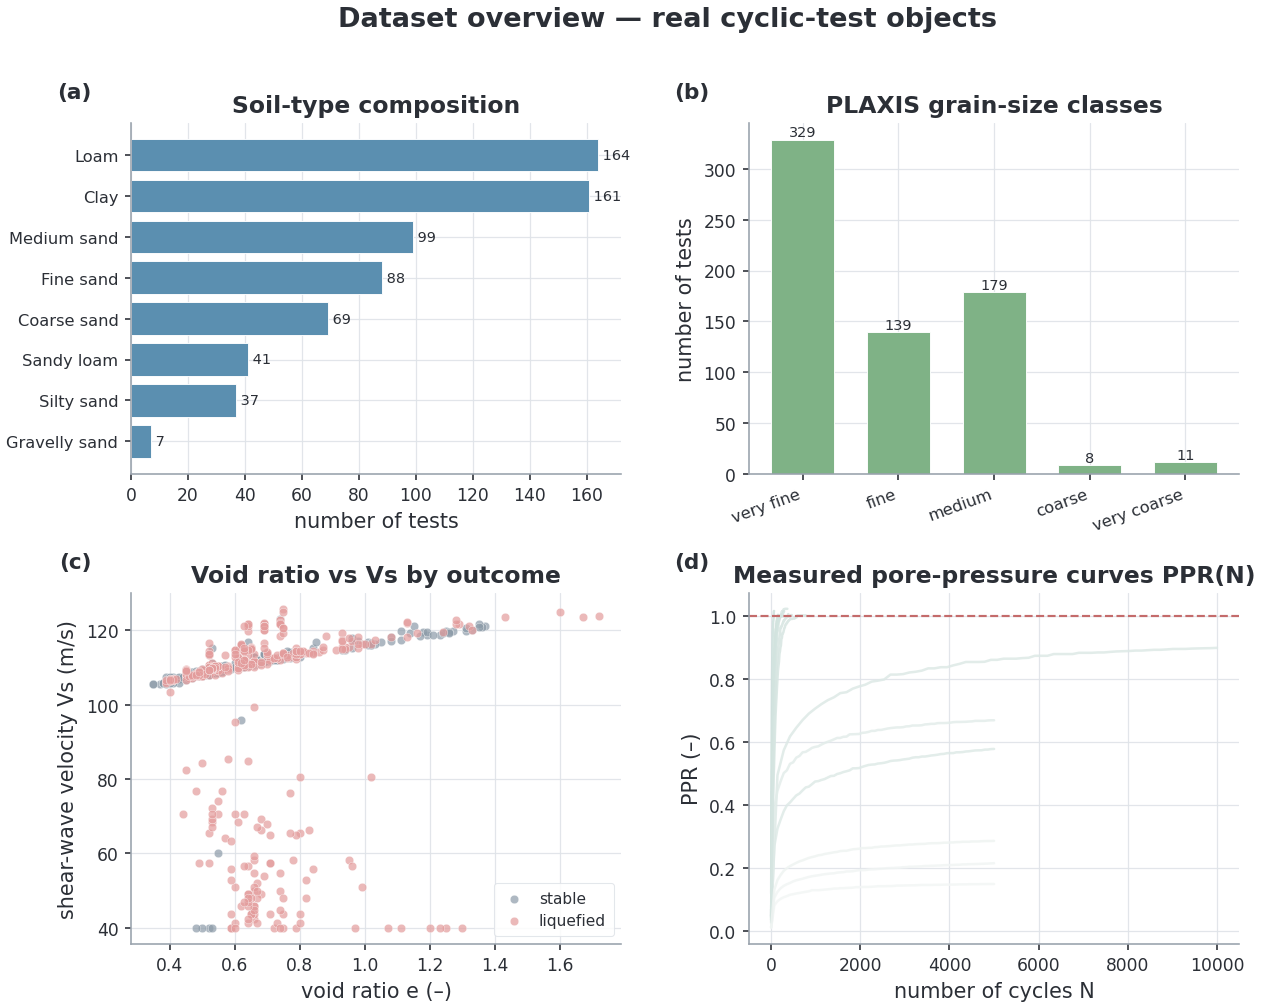

In [2]:
data_overview_panel(meta, cycles, r_obs, valid_mask,
                    soil_label_map=SOIL_DISPLAY_NAMES_EN,
                    title="Dataset overview — real cyclic-test objects",
                    save=SAVE_FIGS, fig_id="5_1_data_overview").show()

## Панель 2 — Физика сопротивления разжижению (CRR)

Кривые CRR(N)=β/N^(1−α) по типам грунта, зависимость CRR15 от относительной плотности и числа
пластичности, разложение параметров α/β — единый блок «физики» для статьи.

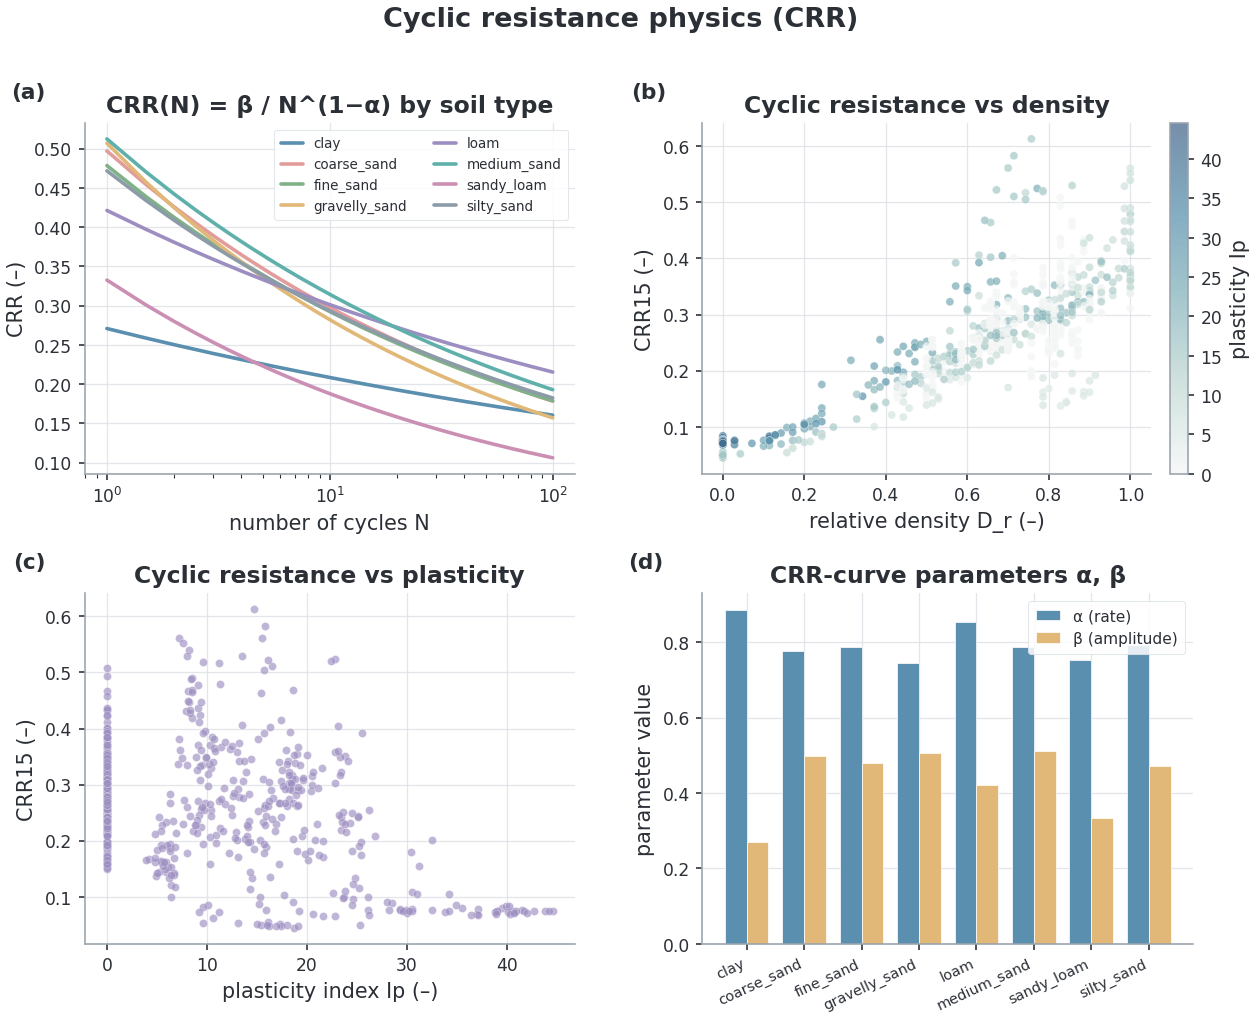

In [3]:
crr_physics_panel(meta, title="Cyclic resistance physics (CRR)",
                  save=SAVE_FIGS, fig_id="5_1_crr_physics").show()

## Панель 3 — Сравнение моделей

P³-скор (публикационная метрика с физическим gate), траекторная ошибка PPR(N), качество
классификации риска (AUROC↔Brier) и ошибка числа циклов до разжижения. Флагманы (DPI-EVT,
EVT-NeuralSSM, DPI-Flow) выделены.

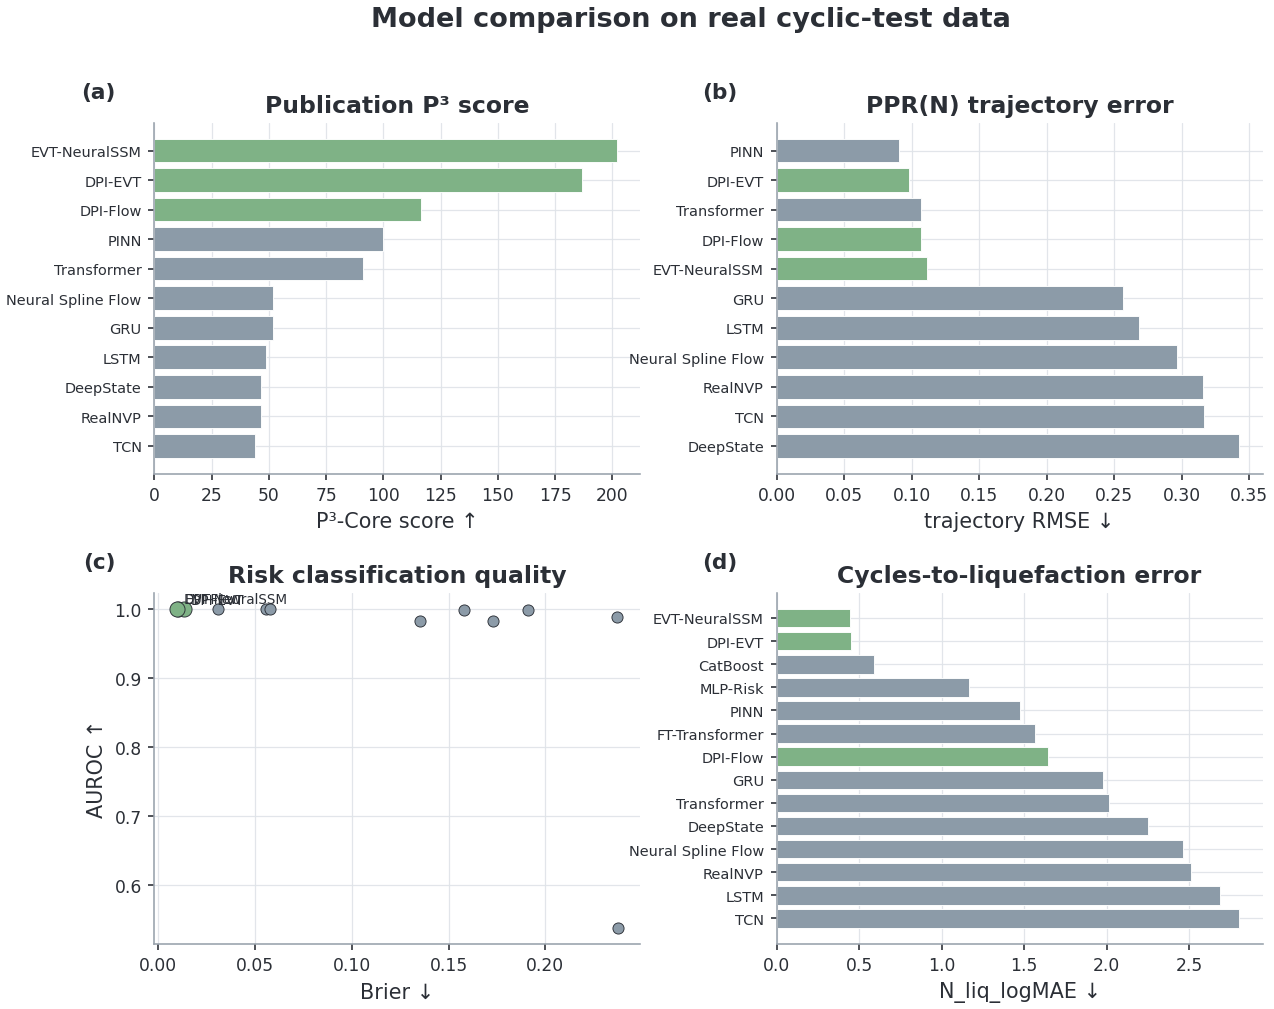

In [4]:
model_leaderboard_panel(leaderboard, score_col="P3_Core_Raw_Score",
                        highlight=("DPI-EVT", "EVT-NeuralSSM", "DPI-Flow"),
                        title="Model comparison on real cyclic-test data",
                        save=SAVE_FIGS, fig_id="5_1_leaderboard").show()

## Итог

Три объединённые панели (`results/figs/5_1_data_overview`, `5_1_crr_physics`, `5_1_leaderboard`)
сохранены в высоком разрешении PNG и векторном PDF — готовы для вставки в статью. Стиль единый
для всех рисунков проекта (пастельная палитра, чистый sans-serif, тонкие оси), задаётся темой
`liquefaction_ai.viz.register_theme`.